In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'medium',
        'figure.figsize': (18, 6),
        'axes.labelsize': 'medium',
        'axes.titlesize':'medium',
        'xtick.labelsize':'medium',
        'ytick.labelsize':'medium'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import time
import datetime
import pytz

NYC_tz = pytz.timezone("America/New_York") 

import sys
sys.path.append("../../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

In [2]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP, _alias_to_cusip
from TB.FixedRateBondsTB import FixedRateBondsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedStructure, UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from TB.STIRFutureOptionsTB import STIRFutureOptionsTB
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP
from TB.IRSwaptionsTB import IRSwaptionsTB
from Query.IRSwaptions import IRSwaptionQuery, IRSwaptionValue

In [3]:
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")

In [4]:
tb = TimeseriesBuilder(
    stirfutureoptions_tb=STIRFutureOptionsTB(stirfo_mdp, show_tqdm=True),
)

start = datetime.date(2026, 2, 1)
end = datetime.date(2026, 3, 24)

queries = [
    STIRFutureOptionQuery(symbol="SR3Z26|25DC", value=STIRFutureOptionValue.IV_NORMAL_BPS),
    STIRFutureOptionQuery(symbol="SR3Z26|25DP", value=STIRFutureOptionValue.IV_NORMAL_BPS),
]

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=queries,
    ignore_cache=True
)
df

2026-03-25 13:05:52,878 - BarchartFetcher - ERROR - Barchart EOD - Empty data error: No columns to parse from file for symbol SQZ26|10000C
ERROR	Task(Task-4) BarchartFetcher:BarchartFetcher.py:_fetch_eod_timeseries()- Barchart EOD - Empty data error: No columns to parse from file for symbol SQZ26|10000C
2026-03-25 13:05:52,883 - BarchartFetcher - ERROR - Barchart EOD - Empty data error: No columns to parse from file for symbol SQZ26|10006C
ERROR	Task(Task-6) BarchartFetcher:BarchartFetcher.py:_fetch_eod_timeseries()- Barchart EOD - Empty data error: No columns to parse from file for symbol SQZ26|10006C
2026-03-25 13:05:52,902 - BarchartFetcher - ERROR - Barchart EOD - Empty data error: No columns to parse from file for symbol SQZ26|10006P
ERROR	Task(Task-7) BarchartFetcher:BarchartFetcher.py:_fetch_eod_timeseries()- Barchart EOD - Empty data error: No columns to parse from file for symbol SQZ26|10006P
2026-03-25 13:05:52,954 - BarchartFetcher - ERROR - Barchart EOD - Empty data error: 

ValueError: Could not resolve delta alias 'SR3Z26|25DC': no priced strikes available near 2026-02-06 for SFRZ26.

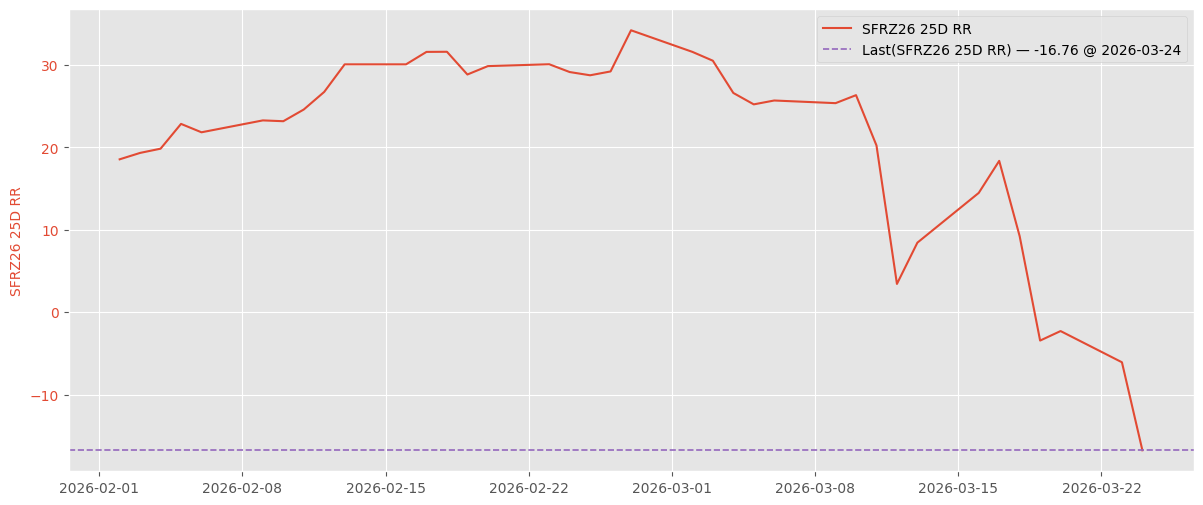

In [ ]:
df["SFRZ26 25D RR"] = df["SR3Z26|25DC OUTRIGHT IV_NORMAL_BPS"] - df["SR3Z26|25DP OUTRIGHT IV_NORMAL_BPS"]

plot, fig, ax, ax2, legend = make_secondary_axis_plot()
plot(
    df["SFRZ26 25D RR"],
    which="left",
    indicators=[
        {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},
        # {"kind": "sma", "window": 252, "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
        # {"kind": "hurst", "hide": True},
        # {"kind": "vol", "returns": "normal", "window": 252, "hide": True},
    ],
)
legend(show_date=True)
plt.show()

## Swaption ATMF Normal Vol Timeseries

In [4]:
swaption_mdp = IRSwaptionMDP(
    source="GSQUANT-QL",
    curve_source="ERIS_EOD_LIVE-QL_BASIC",
)
swaption_tb = IRSwaptionsTB(mdp=swaption_mdp, show_tqdm=True)

In [7]:
start = datetime.date(2025, 1, 1)
end = datetime.date(2026, 6, 18)

queries = [
    # IRSwaptionQuery(curve="USD-SOFR-1D", shorthand="1y1y"),
    IRSwaptionQuery(curve="USD-SOFR-1D", shorthand="10y20y"),
]

df_nvol = swaption_tb.get_timeseries(start=start, end=end, queries=queries)
df_nvol

PRICING IRSWAPTIONS.:   0%|          | 0/1 [00:00<?, ?it/s]WARNING	Task(Task-3) IRSwaptionsTB:IRSwaptionsTB.py:get_timeseries()- No swaption context for curve='USD-SOFR-1D', date='2025-01-01'.
WARNING	Task(Task-3) IRSwaptionsTB:IRSwaptionsTB.py:get_timeseries()- No swaption context for curve='USD-SOFR-1D', date='2025-01-20'.
WARNING	Task(Task-3) IRSwaptionsTB:IRSwaptionsTB.py:get_timeseries()- No swaption context for curve='USD-SOFR-1D', date='2025-02-17'.
WARNING	Task(Task-3) IRSwaptionsTB:IRSwaptionsTB.py:get_timeseries()- No swaption context for curve='USD-SOFR-1D', date='2025-04-18'.
WARNING	Task(Task-3) IRSwaptionsTB:IRSwaptionsTB.py:get_timeseries()- No swaption context for curve='USD-SOFR-1D', date='2025-05-26'.
WARNING	Task(Task-3) IRSwaptionsTB:IRSwaptionsTB.py:get_timeseries()- No swaption context for curve='USD-SOFR-1D', date='2025-06-19'.
WARNING	Task(Task-3) IRSwaptionsTB:IRSwaptionsTB.py:get_timeseries()- No swaption context for curve='USD-SOFR-1D', date='2025-07-04'.
WAR

,USD-SOFR-1D 10Yx20Y RECEIVER BUY ATMF NVOL
Date,
2025-01-02,79.868363
2025-01-03,80.084129
2025-01-06,79.966964
2025-01-07,81.646140
2025-01-08,81.804654
...,...
2026-06-12,75.195110
2026-06-15,74.725550
2026-06-16,73.512745


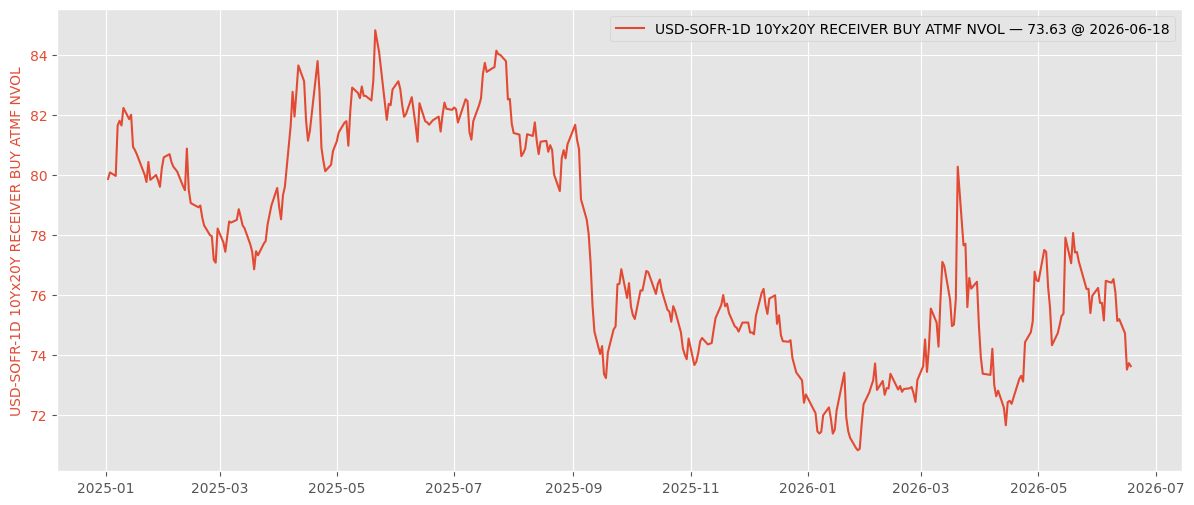

: 

In [ ]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot()
# for col in df_nvol.columns:
#     plot(
#         df_nvol[col],
#         which="left",
#         indicators=[
#             # {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2}},
#         ],
#     )
plot(df_nvol["USD-SOFR-1D 10Yx20Y RECEIVER BUY ATMF NVOL"])
legend(show_date=True)
# ax.set_ylabel("ATMF Normal Vol (bps)")
# ax.set_title("Swaption NVOL — 1Y Expiry")
plt.show()

In [ ]:
queries_expiry = [
    IRSwaptionQuery(curve="USD-SOFR-1D", shorthand="1m10y", name="1Mx10Y"),
    IRSwaptionQuery(curve="USD-SOFR-1D", shorthand="3m10y", name="3Mx10Y"),
    IRSwaptionQuery(curve="USD-SOFR-1D", shorthand="6m10y", name="6Mx10Y"),
    IRSwaptionQuery(curve="USD-SOFR-1D", shorthand="1y10y", name="1Yx10Y"),
    IRSwaptionQuery(curve="USD-SOFR-1D", shorthand="5y10y", name="5Yx10Y"),
    IRSwaptionQuery(curve="USD-SOFR-1D", shorthand="10y10y", name="10Yx10Y"),
]

df_expiry = swaption_tb.get_timeseries(start=start, end=end, queries=queries_expiry)
df_expiry

In [ ]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot()
for col in df_expiry.columns:
    plot(
        df_expiry[col],
        which="left",
        indicators=[
            {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2}},
        ],
    )
legend(show_date=True)
ax.set_ylabel("ATMF Normal Vol (bps)")
ax.set_title("Swaption NVOL — 10Y Tail, Expiry Term Structure")
plt.show()